# **Fashion MNIST Image Recognition using Neural Networks**

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D

from sklearn.metrics import classification_report, confusion_matrix


**Load Dataset**

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()  # Loading entire MNIST Dataset
print('Training images:',x_train.shape)
print('Training image Labels: ',y_train.shape)
print('Testing images: ',x_test.shape)
print('Testing image Labels: ',y_test.shape)

Training images: (60000, 28, 28)
Training image Labels:  (60000,)
Testing images:  (10000, 28, 28)
Testing image Labels:  (10000,)


# **Data Exploration**

In [4]:
# Creating a list of 10 class names for MNIST dataset
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]
for i, class_name in enumerate(class_names):
  print(i, '-->',class_name)

0 --> T-shirt/top
1 --> Trouser
2 --> Pullover
3 --> Dress
4 --> Coat
5 --> Sandal
6 --> Shirt
7 --> Sneaker
8 --> Bag
9 --> Ankle boot


Class name:  Bag


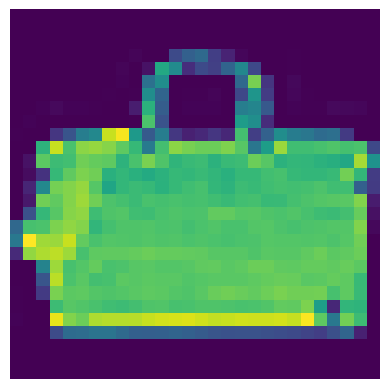

In [5]:
image = x_train[99]      # Actual image from train dataset
label = y_train[99]      # Actual image label (i.e 0-9)
print('Class name: ',class_names[label])
plt.imshow(image)
plt.axis('off')
plt.show()

In [6]:
print('Minimum pixel value:',image.min())
print('Maximum pixel value:',image.max())
print('Image Shape:',image.shape)
print('First 5 rows of pixel values\n',image[:5])  # Print first 5 rows of pixel values

Minimum pixel value: 0
Maximum pixel value: 255
Image Shape: (28, 28)
First 5 rows of pixel values
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   3   0   0  57  78  87  47  25   4
    0   0   0   1   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   3   0  12 154 123  33  57  48  82 118
   56   0   0   1   0   0   0   0   0   0]]


**Data Cleaning**

In [9]:
print('NaN values in training set:',np.isnan(x_train).sum())
print('NaN values in testing set:',np.isnan(x_test).sum())

NaN values in training set: 0
NaN values in testing set: 0


In [11]:
class_counts = np.bincount(y_train)  # Returns list of 10 6000s
print('The numbers of images belonging to each class:')
for i, count in enumerate(class_counts):
  print(f'{i} --> {class_names[i]} : {count}')

The numbers of images belonging to each class:
0 --> T-shirt/top : 6000
1 --> Trouser : 6000
2 --> Pullover : 6000
3 --> Dress : 6000
4 --> Coat : 6000
5 --> Sandal : 6000
6 --> Shirt : 6000
7 --> Sneaker : 6000
8 --> Bag : 6000
9 --> Ankle boot : 6000


# **Expolatory Data Analysis (EDA)**

**Displaying multiple images**

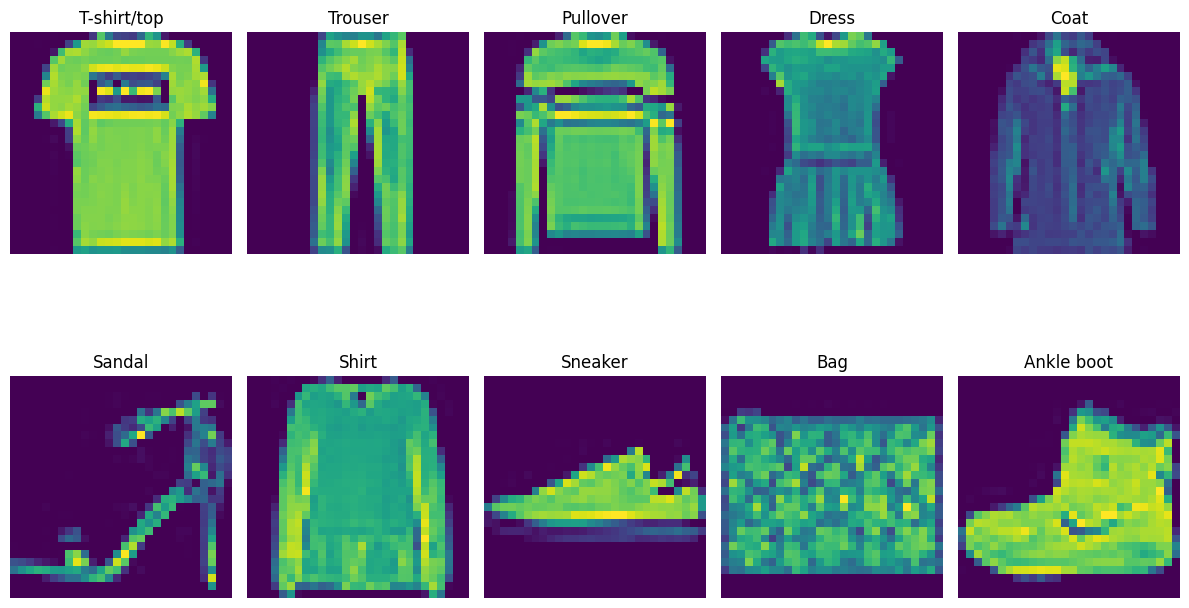

In [12]:
plt.figure(figsize=(12,8))

for class_index in range(10):
  ImgIndex = np.where(y_train == class_index)[0][0]  # finding first image belonging to the current class
  plt.subplot(2, 5, class_index + 1)  # Creating a subplot in a 2-row, 5-column grid
  plt.imshow(x_train[ImgIndex])  # Displaying selected image
  plt.title(class_names[class_index])  # Adding image names
  plt.axis('off')

plt.tight_layout()
plt.show()

**Visualizing multiple RANDOM examples**

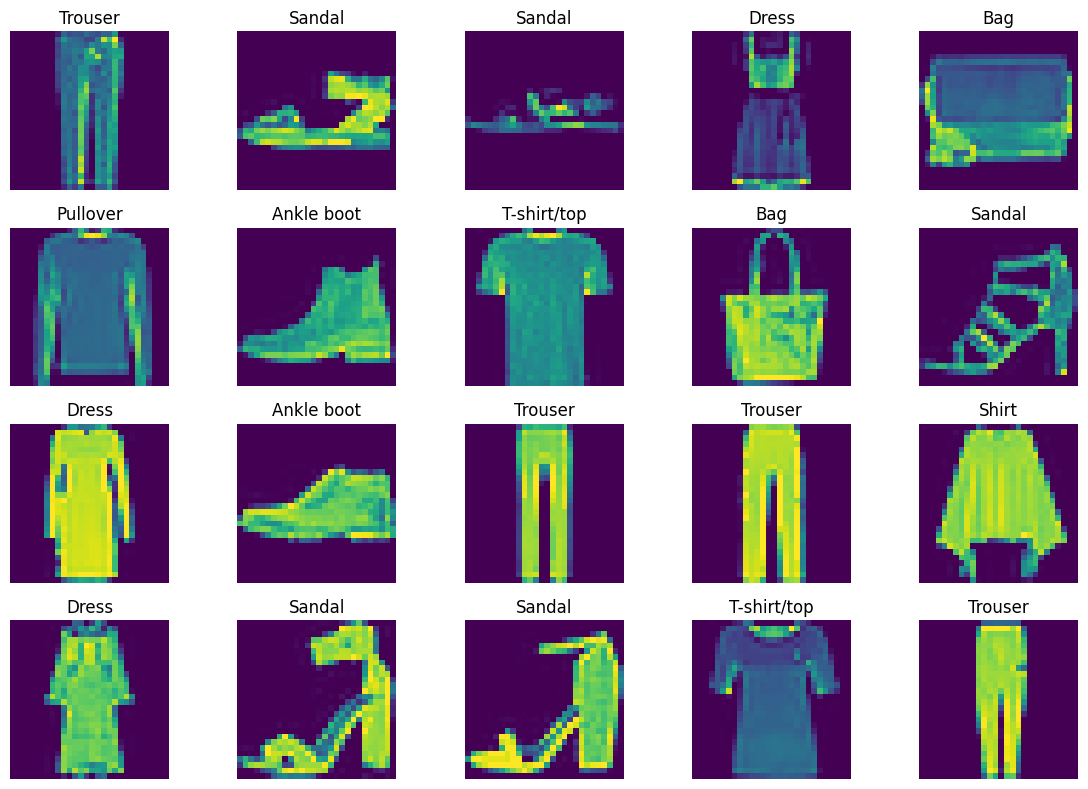

In [13]:
rng = np.random.default_rng(42)  # To generate reproducile results everytime you run
random_indices = rng.choice(len(x_train), size=20, replace=False) # Creates a list of 20 random indices
plt.figure(figsize=(12,8))

for plot_number, image_index in enumerate(random_indices):
  plt.subplot(4, 5, plot_number + 1)
  plt.imshow(x_train[image_index])
  label = y_train[image_index]
  plt.title(class_names[label])
  plt.axis('off')

plt.subplots_adjust(hspace=0.5)
plt.tight_layout()

Now we are going to create a validation set from "Training samples" and NOT the 'Testing Samples" for **tuning our model.**

So, we are splitting the 60,000 training samples instead

**Split the original training images ito training and validation datasets**

In [14]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,  # Training images
    y_train,  # Training image labels
    test_size=0.2, # 20% for validation from 60,000
    random_state=42,  # Making the split reproducible
    stratify=y_train  # Preserving class distribution in both sets
)
print(f'Training images shape:{x_train.shape}')
print(f'Training image labels shape:{y_train.shape}')
print(f'Validation images shape:{x_val.shape}')
print(f'Validation image labels shape:{y_val.shape}')

Training images shape:(48000, 28, 28)
Training image labels shape:(48000,)
Validation images shape:(12000, 28, 28)
Validation image labels shape:(12000,)


 **Our Final dataset structure looks like this:**




                  Fashion-MNIST
                       │
            ┌──────────┴──────────┐
            │                     │
       Training                  Test
          set                     set
        (60,000)               (10,000)
           │
      ┌────┴────┐
      │         │
    Train      Validation
     set         set
    (48,000)    (12,000)




In [15]:
train_counts = np.bincount(y_train)  # Training labels counts (i.e 48000)
val_counts = np.bincount(y_val)      # Validation labels counts (i.e 1200)
test_counts = np.bincount(y_test)    # Testing labels counts (i.e 1000)

distribution_data = pd.DataFrame({
    'Class':class_names,  # Store all the class names
    'Training':train_counts,  # Store training counts
    'Validation':val_counts,  # Store validations labels
    'Testing':test_counts   # Store testing labels
})
distribution_data

,Class,Training,Validation,Testing
0,T-shirt/top,4800,1200,1000
1,Trouser,4800,1200,1000
2,Pullover,4800,1200,1000
3,Dress,4800,1200,1000
4,Coat,4800,1200,1000
5,Sandal,4800,1200,1000
6,Shirt,4800,1200,1000
7,Sneaker,4800,1200,1000
8,Bag,4800,1200,1000
9,Ankle boot,4800,1200,1000


**Investigating image dimensions**

In [16]:
print('Training set image dimensions:',x_train.shape[1:])
print('Validation set image dimensions:',x_val.shape[1:])
print('Testing set image dimensions:',x_test.shape[1:])

Training set image dimensions: (28, 28)
Validation set image dimensions: (28, 28)
Testing set image dimensions: (28, 28)


# **Data Preprocessing**

Neural Networks generally train better when inputs are scaled

Our pixels values curretly ranges from `0 --> 255`.

So we have to **normalize** them to `0 --> 1`

<font color="red"><b>`RUN THE BELOW CELL ONLY ONCE!!!`</b></font>

In [17]:
# Converting image pixels values from int to floating point numbers
x_train = x_train.astype('float32')
x_val = x_val.astype('float32')
x_test = x_test.astype('float32')

# Dividing image pixels by 255 so their vales fall between 0 and 1
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# Visualize image pixel values after Normalization (RUN only Once)
print('Training pixel range:',x_train.min(),'to',x_train.max())
print('Validation pixel range:',x_val.min(),'to',x_val.max())
print('Testing pixel image:',x_test.min(),'to',x_test.max())

Training pixel range: 0.0 to 1.0
Validation pixel range: 0.0 to 1.0
Testing pixel image: 0.0 to 1.0


## **More EDA**

**Pixel intensity distribution**

In [18]:
print(f'Mean normalized pixel value: {x_train.mean():.2f}')
print(f'Pixel standard deviation: {x_train.std():.2f}')

Mean normalized pixel value: 0.29
Pixel standard deviation: 0.35


**Average image of every class**

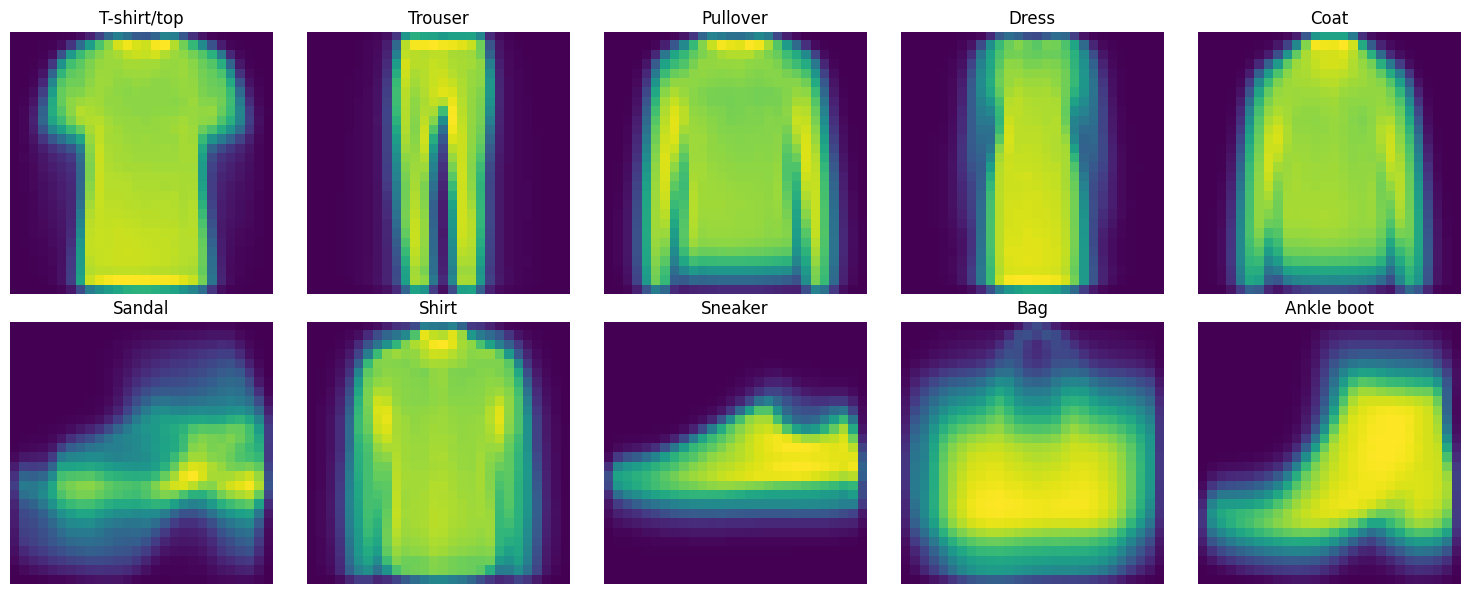

In [19]:
plt.figure(figsize=(15,6))
for class_id in range(10):
  class_images = x_train[y_train == class_id] # Selecting all training images belonging to this class
  avg_image = class_images.mean(axis=0)  # Calculating avg pixel value at every image location
  plt.subplot(2, 5, class_id + 1)
  plt.imshow(avg_image)
  plt.title(class_names[class_id])
  plt.axis('off')

plt.tight_layout()
plt.show()

# **Model Building & Training**

## **Artificial Neural Network Baseline**

In [20]:
# Building ANN Architecture
ann = Sequential([
    Input(shape=(28, 28)),  # Telling keras each input is 28x28
    Flatten(),   # Converting 28x28 image into 1D vector of 784 values
    Dense(128, activation='relu'),  # Creating fully connected layer with 128 neurons
    Dropout(0.20),  # Randomly deactivating 20% neurons during training
    Dense(10, activation='softmax')   # Creating 10 output neurons, one for each clothing class
])
ann.compile(
    optimizer='adam',   # Adam optimization algo to update model's weight
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

**Early Stopping & Learning Rate Scheduling**

In [21]:
# Stopping the training if validation loss does not improve for 5 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss',  # Tells the callback to monitor validation loss
    patience=5,     # Allows 5 consecutive epochs without improvement before stopping training
    restore_best_weights=True
)
# Reducing the learning rate when validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Multiplies the current learning rate by 0.5 when improvement stops
    patience=2, # wait for 2 epochs
    min_lr=0.000001 # Prevents the learning rate from becoming smaller than 0.000001
)

**Training the ANN**

In [22]:
history_ann = ann.fit(
    x_train,  # Provides the training images
    y_train,  # Provides training labels
    validation_data=(x_val, y_val),  # Provides validation images and labels for evaluating the model after each epoch
    epochs=30,  # Allowing the model to train maximum of 30 epochs
    batch_size=128,  # Processes 128 images at a time before updating the model weights
    callbacks=[early_stop, reduce_lr],
    verbose=1 # Displays training progress
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7801 - loss: 0.6314 - val_accuracy: 0.8519 - val_loss: 0.4327 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8431 - loss: 0.4429 - val_accuracy: 0.8610 - val_loss: 0.3874 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8574 - loss: 0.3972 - val_accuracy: 0.8682 - val_loss: 0.3635 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8676 - loss: 0.3708 - val_accuracy: 0.8761 - val_loss: 0.3425 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8729 - loss: 0.3514 - val_accuracy: 0.8793 - val_loss: 0.3335 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8758 - loss: 0.3375 - val_accuracy: 0.8817 - val_loss: 0.3272 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8808 - loss: 0.3279 - 

**Training vs Validation accuracy**

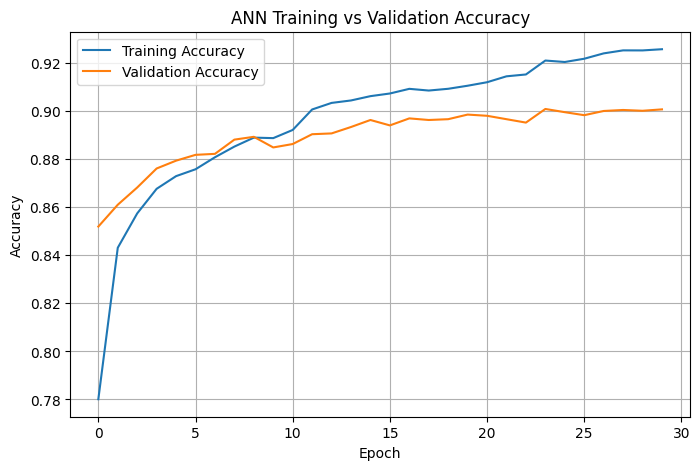

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
test_loss_ann, test_accuracy_ann = ann.evaluate(
    x_test,
    y_test,
    verbose=0
)
print(f'Test Loss: {test_loss_ann:.2%}')
print(f'Test Accuracy: {test_accuracy_ann:.2%}')

Test Loss: 31.16%
Test Accuracy: 89.02%


In [25]:
ann_probabilities = ann.predict(x_test, verbose=0)  # Generating probabilities with x_test dataset
ann_predictions = np.argmax(
    ann_probabilities,   # Selecting the class with highest probability for each test image
    axis=1
)
print(classification_report(
    y_test,
    ann_predictions,
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.86      0.86      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.80      0.80      1000
       Dress       0.89      0.90      0.89      1000
        Coat       0.79      0.82      0.81      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.72      0.69      0.71      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.97      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



* **Precision:** Of all the samples predicted as positive, how many were actually positive.
* **Recall:** Of all the actual positive samples, how many were correctly identified.
* **F1-score:** The harmonic mean of precision and recall, balancing both metrics.
* **Support:** The number of actual samples belonging to each class.


**Confusion Matrix**

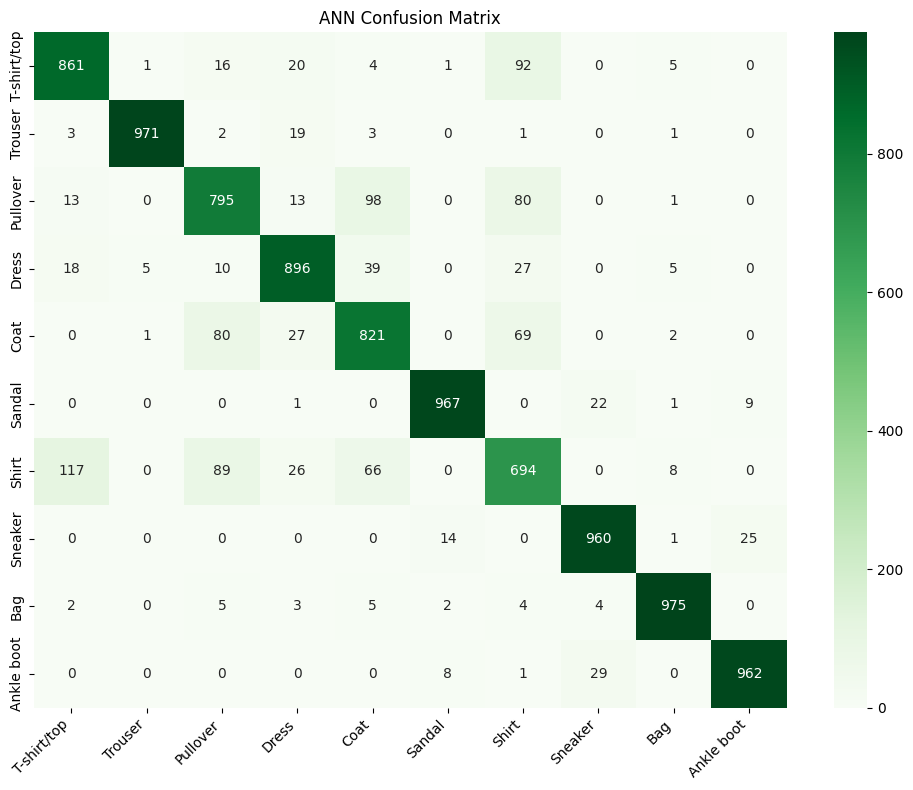

In [26]:
ann_cm = confusion_matrix(
    y_test,
    ann_predictions
)
plt.figure(figsize=(10,8))
sns.heatmap(
    ann_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('ANN Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Convolutional Neural Network Baseline**

A CNN is a type of neural network particularly suited for images
Instead of immediately converting the image into a long list of 784 numbers like the ANN, a CNN can learn spatial patters like edges, curves, shapes, textures etc.

Unlike ANN, CNN expects an **additional channel dimension**

- Our images (ANN) are: **28x28**
- CNN expects: **28x28x1**

**(1 represents one grayscale channel)**


**Preparing data for CNN**

In [27]:
x_train_cnn = x_train[...,np.newaxis] # Adds a new dimension at the end so each image becomes 28x28x1
x_val_cnn = x_val[...,np.newaxis]  # Adds the grayscale channel dimension to the validation images
x_test_cnn = x_test[...,np.newaxis] # Adds the grayscale channel dimension to the test images

In [28]:
print(f'CNN Training Samples: {x_train_cnn.shape}')
print(f'CNN Validation Samples: {x_val_cnn.shape}')
print(f'CNN Testing Samples: {x_test_cnn.shape}')

CNN Training Samples: (48000, 28, 28, 1)
CNN Validation Samples: (12000, 28, 28, 1)
CNN Testing Samples: (10000, 28, 28, 1)


In [29]:
# Building CNN Architecture
cnn = Sequential([
    Input(shape=(28, 28, 1)), # Defining the input as 28x28 grayscale image with 1 channel
    Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'), # Uses 32 filters of size 3x3 to detect basic visual features such as edges and curves
    MaxPooling2D(pool_size=(2,2)), # Reducing the feature-map size by taking the maximum value from each 2x2 region
    Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),  # Using 64 filters to learn more complex visual patterns from the previous features
    MaxPooling2D(pool_size=(2,2)), # further reducing the spatial size of the feature maps
    Flatten(),  # Converting the final 2D feature maps into 1D vector
    Dense(128, activation='relu'),   # Creating a fully connected layer with 128 neurons to learn high-level combinations of features
    Dropout(0.30),  # Randomly disables 30 percent of neurons during training to help reduce overfitting
    Dense(10, activation='softmax')  # Creating 10 output neurons, one for each clothing class (trouser, sandal etc)
])
cnn.compile(
    optimizer='adam',  # Adam optimization algo to update model's weight
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

**Training the CNN**

In [30]:
cnn_history = cnn.fit(
    x_train_cnn,   # Training samples for CNN
    y_train,   # Training labels
    validation_data=(x_val_cnn, y_val), # Provides validation images and labels for evaluating model after each epoch
    epochs=30,   # Allows the model to train for maximum 30 epochs
    batch_size=128, # Processes 128 images at a time before updating the model weights
    callbacks=[early_stop, reduce_lr],  # Applying EarlyStopping and learning scheduling techniques
    verbose=1  # verbose=1 = Displays training progress
    )

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 92ms/step - accuracy: 0.7937 - loss: 0.5736 - val_accuracy: 0.8736 - val_loss: 0.3495 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.8702 - loss: 0.3604 - val_accuracy: 0.8913 - val_loss: 0.3023 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.8936 - loss: 0.2972 - val_accuracy: 0.9026 - val_loss: 0.2695 - learning_rate: 5.0000e-04
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 107ms/step - accuracy: 0.9011 - loss: 0.2763 - val_accuracy: 0.9093 - val_loss: 0.2578 - learning_rate: 5.0000e-04
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 0.9061 - loss: 0.2581 - val_accuracy: 0.9118 - val_loss: 0.2453 - learning_rate: 5.0000e-04
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.9104 - loss: 0.2456 - val_accuracy: 0.9159 - val_loss: 0.2357 - learning_rate: 5.0000e-04
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 36s 95ms/step - acc

Important: **30 is the maximum**, not necessarily the number of **epochs** it will actually complete. EarlyStopping may **stop** it earlier

**Training vs Validation Accuracy**

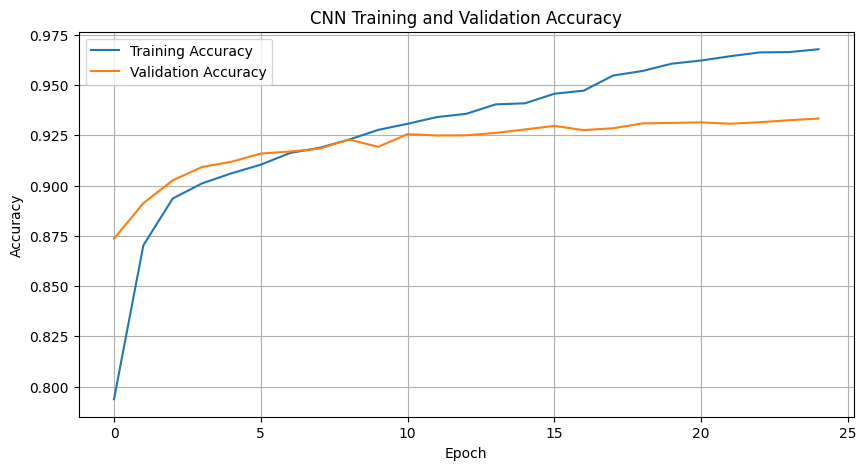

In [31]:
plt.figure(figsize=(10,5))
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
test_loss_cnn, test_accuracy_cnn = cnn.evaluate(
    x_test_cnn,
    y_test,
    verbose=0
)
print(f'Test Loss: {test_loss_cnn:.2%}')
print(f'Test Accuracy: {test_accuracy_cnn:.2%}')

Test Loss: 22.74%
Test Accuracy: 92.37%


In [33]:
cnn_probabilities = cnn.predict(x_test_cnn) # Generating probabilities with x_test_cnn dataset
cnn_predictions = np.argmax(cnn_probabilities, axis=1) # Selects the class with highest probability for each test image
print(classification_report(
    y_test,
    cnn_predictions,
    target_names=class_names
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.88      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.88      0.89      0.88      1000
       Dress       0.93      0.92      0.93      1000
        Coat       0.86      0.90      0.88      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.80      0.76      0.78      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



* **Precision:** Of all the samples predicted as positive, how many were actually positive.
* **Recall:** Of all the actual positive samples, how many were correctly identified.
* **F1-score:** The harmonic mean of precision and recall, balancing both metrics.
* **Support:** The number of actual samples belonging to each class.


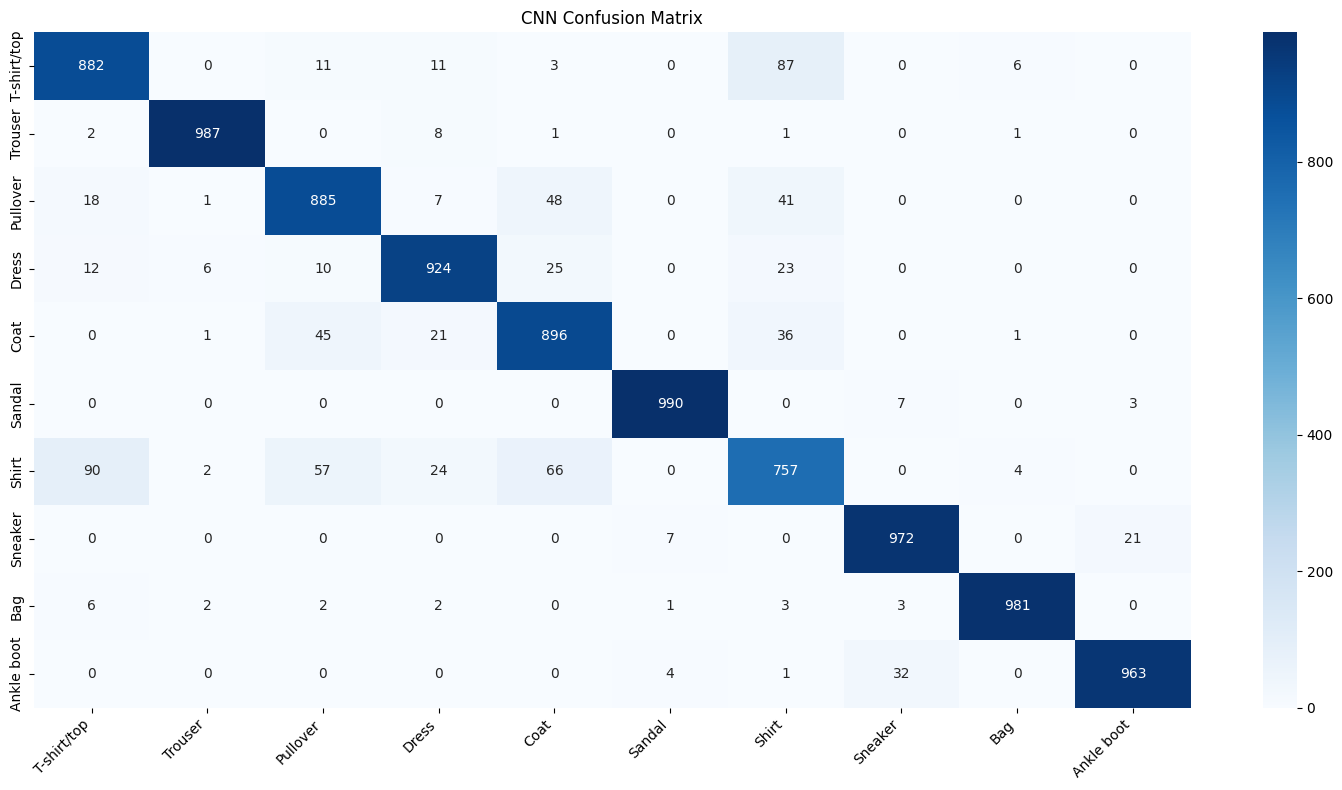

In [34]:
cnn_cm = confusion_matrix(y_test, cnn_predictions)
plt.figure(figsize=(15,8))
sns.heatmap(
    cnn_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('CNN Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Models Evaluation**

In [35]:
models_comparison = pd.DataFrame({
    'Model': ['ANN', 'CNN'],
    'Test Accuracy':[test_accuracy_ann, test_accuracy_cnn]
})
models_comparison

,Model,Test Accuracy
0,ANN,0.8902
1,CNN,0.9237


## **Save the model**

In [36]:
if test_accuracy_cnn > test_accuracy_ann:
  best_model = cnn
  best_model_name = 'Convolutional Neural Network (CNN)'
else:
  best_model = ann
  best_model_name = 'Artificial Neural Network (ANN)'
print(f'Best Model is {best_model_name}')

Best Model is Convolutional Neural Network (CNN)


# **Prediction Function (User-friendly)**

In [37]:
# We know our different classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [38]:
def predict_test_image(index):
  image = x_test[index]   # Retrieves the test image at user's entered index
  actual_label = y_test[index]   # Retrieves the actual class label of that test image
  image_for_prediction = x_test_cnn[index]  # Retrieves the already preprocessed CNN version of that image
  image_for_prediction = np.expand_dims(image_for_prediction, axis=0) # Adds a batch dimension becuz the CNN expects a batch of images
  probabilities = best_model.predict(image_for_prediction, verbose=0)[0]  # Sends the selected image through our trained CNN and obtains probabilities for all 10 classes
  predicted_index = np.argmax(probabilities) # Finds the class with highest probability
  predicted_class = class_names[predicted_index]  # Takes that predicted class as clothing name
  actual_class = class_names[actual_label]    # Takes the actual class as clothing name
  confidence = probabilities[predicted_index] * 100  # Converts the highest prediction probability into a percentage

  print('=' * 50)
  print("           FASHION-MNIST AI PREDICTOR")
  print("=" * 50)
  print(f'Test Image Number: {index}')
  print(f'Predicted Class: {predicted_class}')
  print(f'Confidence: {confidence:.2f}%')
  print('=' * 50)

  print('Top 3 Predictions:')
  top_indices = np.argsort(probabilities)[::-1][:3]  # Finds 3 classes with highest prediction probabilities

  for i, class_index in enumerate(top_indices, start=1):  # Loops through the three highest probability classes
     probability = probabilities[class_index]  * 100   # Converts the probability of the current class into a percentage
     print(f'{i}. {class_names[class_index]} : {probability:.2f}%')

  if predicted_index == actual_label:
    print('\nPrediction Result: CORRECT ✓ (Vamooos)')
  else:
    print('\nPrediction Result: INCORRECT ✗ (Lo siento)')

  print('=' * 50)

  plt.figure(figsize=(5,5))
  plt.imshow(image)
  plt.title(f'Actual: {actual_class}\nPredicted: {predicted_class} \n({confidence:.2f}%)')
  plt.axis('off')
  plt.show()

## **User Input**

Enter a test image number between 0 and 9999: 677
           FASHION-MNIST AI PREDICTOR
Test Image Number: 677
Predicted Class: T-shirt/top
Confidence: 99.80%
Top 3 Predictions:
1. T-shirt/top : 99.80%
2. Shirt : 0.19%
3. Pullover : 0.00%

Prediction Result: CORRECT ✓ (Vamooos)


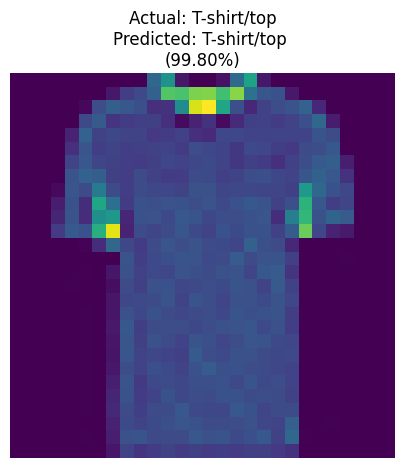

In [39]:
index = int(input('Enter a test image number between 0 and 9999: '))
if 0 <= index < len(x_test):
  predict_test_image(index)
else:
  print('Invalid image number Please enter a number between 0 and 9999.')


**You can RUN the above cell again to enter your own choice :)**

# **Project Summary**

This project builds an **Image Classification system for the Fashion-MNIST dataset** using Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN). The workflow includes image exploration, preprocessing, normalization, model training, evaluation, confusion-matrix analysis, and prediction of individual clothing images.

## **Dataset Overview**

The **Fashion-MNIST** dataset contains grayscale images of clothing items belonging to 10 different categories.

| Class | Clothing Category |
| ----: | ----------------- |
|     0 | T-shirt/top       |
|     1 | Trouser           |
|     2 | Pullover          |
|     3 | Dress             |
|     4 | Coat              |
|     5 | Sandal            |
|     6 | Shirt             |
|     7 | Sneaker           |
|     8 | Bag               |
|     9 | Ankle boot        |

The dataset contains **60,000 training images and 10,000 testing images**, with each image having a size of **28 × 28 pixels**.

## **Project Workflow**

### **1. Data Exploration**

The project explores the dataset by checking image and label shapes, pixel ranges, class distributions, and visualizing individual as well as random sample images.

Images from all 10 clothing categories are also displayed to understand the visual differences between classes.

### **2. Data Preparation**

The original training data is divided into:

* **48,000 training images**
* **12,000 validation images**
* **10,000 test images**

The split uses stratification to maintain the class distribution.

Pixel values are converted from integers to floating-point values and normalized from **`0–255` to `0–1`**.

### **3. ANN Model**

A baseline Artificial Neural Network was created using:

* Flatten layer
* Dense layer with 128 neurons
* ReLU activation
* 20% Dropout
* 10-neuron Softmax output layer

Early Stopping and ReduceLROnPlateau were used during training to improve training stability and reduce overfitting.

> **ANN Test Accuracy: 89.02%**

### **4. CNN Model**

A Convolutional Neural Network was then built specifically for image classification.

The architecture includes:

* Conv2D with 32 filters
* MaxPooling2D
* Conv2D with 64 filters
* MaxPooling2D
* Flatten
* Dense layer with 128 neurons
* 30% Dropout
* 10-neuron Softmax output layer

The CNN achieved:

> **Test Accuracy: 92.37%**

## Model Performance

| Model   | Test Accuracy |  Test Loss |
| ------- | ------------: | ---------: |
| ANN     |        89.02% |     31.16% |
| **CNN** |    **92.37%** | **22.74%** |

Based on test accuracy, the **CNN was selected as the final model**.

### CNN Classification Performance

| Class       | Precision | Recall | F1-Score |
| ----------- | --------: | -----: | -------: |
| T-shirt/top |      0.87 |   0.88 |     0.88 |
| Trouser     |      0.99 |   0.99 |     0.99 |
| Pullover    |      0.88 |   0.89 |     0.88 |
| Dress       |      0.93 |   0.92 |     0.93 |
| Coat        |      0.86 |   0.90 |     0.88 |
| Sandal      |      0.99 |   0.99 |     0.99 |
| Shirt       |      0.80 |   0.76 |     0.78 |
| Sneaker     |      0.96 |   0.97 |     0.97 |
| Bag         |      0.99 |   0.98 |     0.98 |
| Ankle boot  |      0.98 |   0.96 |     0.97 |

The model performs particularly well on **Trousers, Sandals, and Bags**, while **Shirt** is comparatively more difficult to classify.

## **Prediction System**

A user-friendly `predict_test_image()` function was created to classify an individual test image.

For a selected image, the system displays:

* Actual clothing category
* Predicted category
* Prediction confidence
* Top 3 predictions
* Whether the prediction is correct or incorrect
* The selected image with its prediction

The user can enter any test-image index from **0 to 9,999** to interactively test the trained CNN.

## **Conclusion**

This project demonstrates an end-to-end **deep-learning image classification pipeline** using Fashion-MNIST. An ANN baseline achieved **89.02% accuracy**, while the CNN improved performance to **92.37%**, making it the final selected model. The project also includes visual EDA, image normalization, regularization, confusion-matrix evaluation, and an interactive prediction function for classifying individual clothing images.
